# Base 4 — Gráficos exploratórios

O foco é `T (degC)`. Os gráficos mostram a série completa, um trecho ampliado, padrões intradiários e semanais, sazonalidade mensal, distribuição, lacunas e autocorrelação.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT / "src"))
from series_temporais.reporting.graficos_exploratorios import aplicar_estilo, plotar_acf

aplicar_estilo()

DATA_PATH = Path("../../bases/grupo4/grupo4.csv")
df = pd.read_csv(DATA_PATH)

df["Date Time"] = pd.to_datetime(
    df["Date Time"], format="%d.%m.%Y %H:%M:%S", errors="coerce"
)

numeric_cols = [c for c in df.columns if c != "Date Time"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols] = df[numeric_cols].replace(-9999, np.nan)
df = df.sort_values("Date Time").reset_index(drop=True)

# Consolidar duplicidades para não contar duas vezes o mesmo instante.
df = (
    df.groupby("Date Time", as_index=False)[numeric_cols]
      .mean()
      .sort_values("Date Time")
)

# Tornar as lacunas explícitas.
idx = pd.date_range(df["Date Time"].min(), df["Date Time"].max(), freq="10min")
df = df.set_index("Date Time").reindex(idx)
df.index.name = "Date Time"
df = df.reset_index()

target = df.dropna(subset=["T (degC)"]).copy()
target["hour_decimal"] = target["Date Time"].dt.hour + target["Date Time"].dt.minute / 60
target["hour"] = target["Date Time"].dt.hour
target["day_of_week"] = target["Date Time"].dt.dayofweek
target["month"] = target["Date Time"].dt.month

print("Observações na grade:", len(df))
print("Observações com temperatura:", len(target))


Observações na grade: 420768
Observações com temperatura: 420224


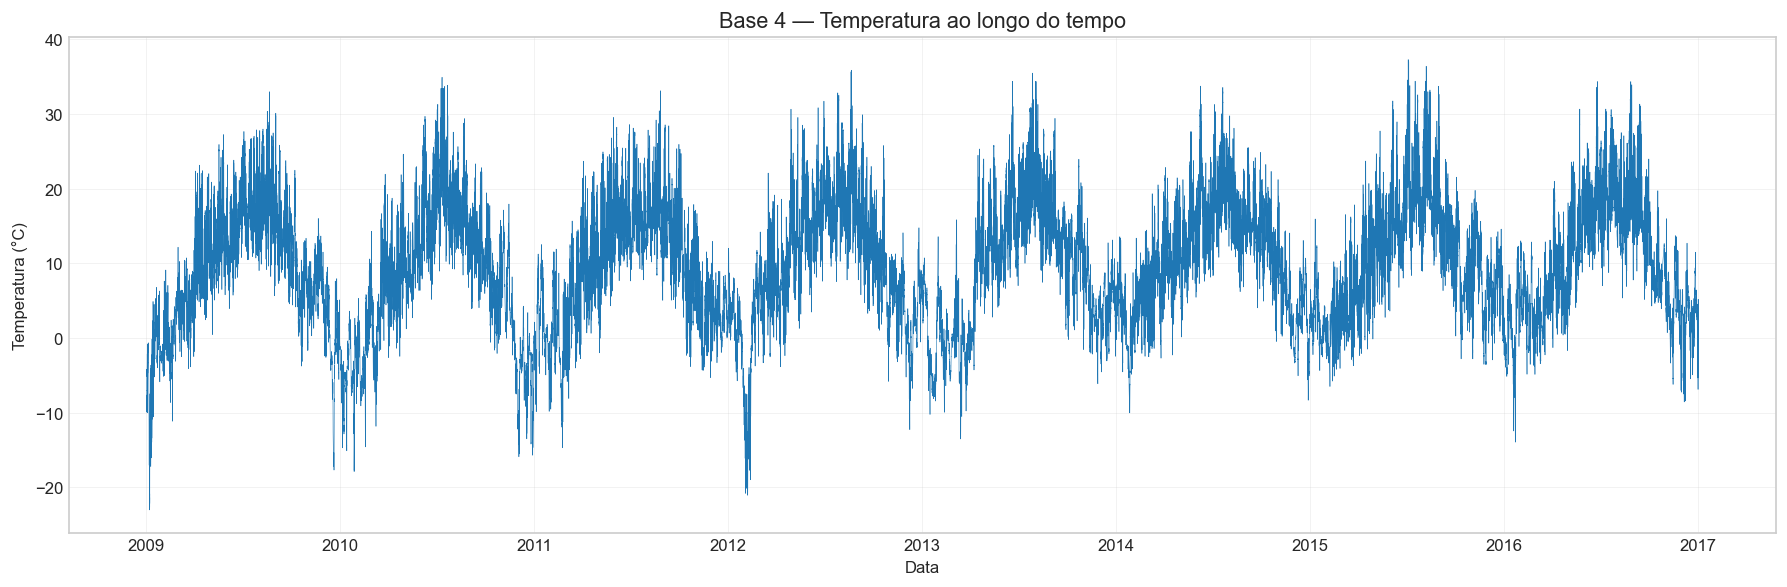

In [2]:
# 1. Série temporal completa
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(target["Date Time"], target["T (degC)"], linewidth=0.35)
ax.set_title("Base 4 — Temperatura ao longo do tempo")
ax.set_xlabel("Data")
ax.set_ylabel("Temperatura (°C)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


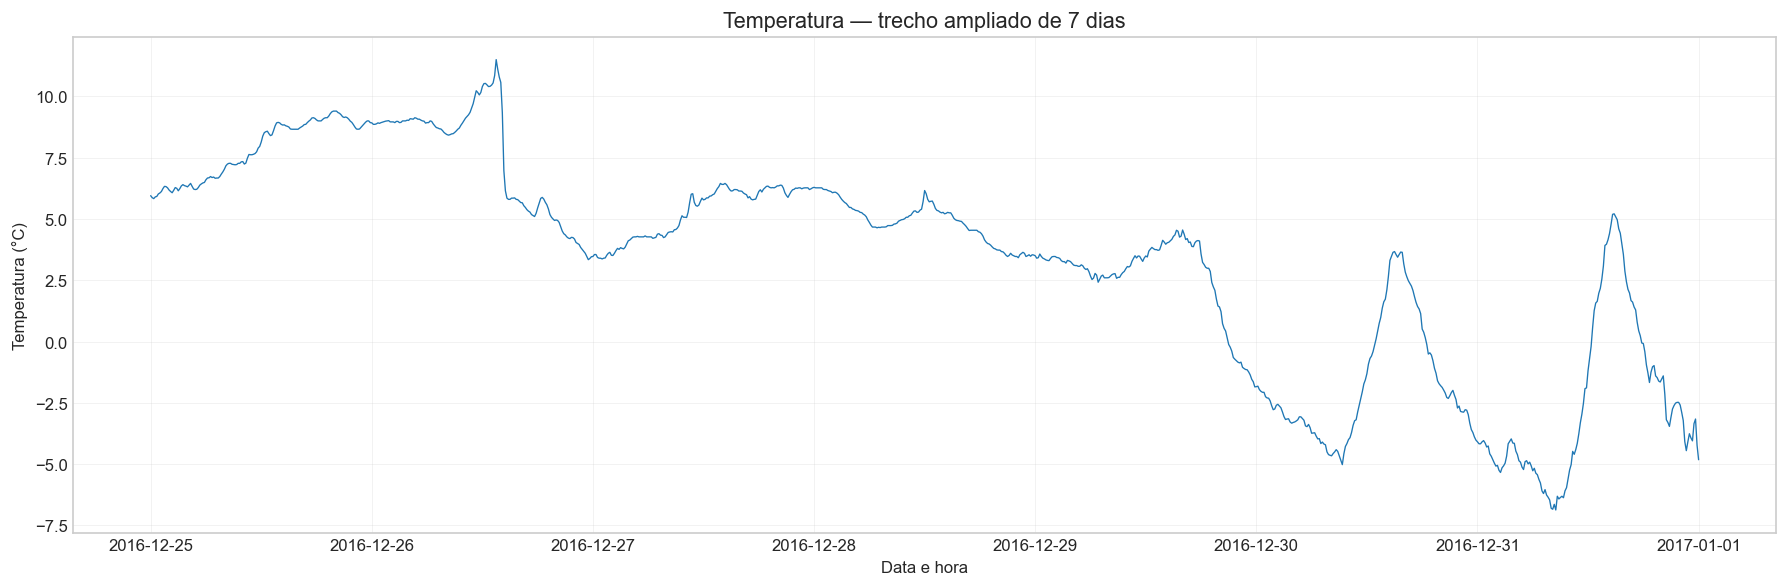

In [3]:
# 2. Trecho ampliado: últimos 7 dias disponíveis
end = target["Date Time"].max()
window = target[target["Date Time"] >= end - pd.Timedelta(days=7)]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(window["Date Time"], window["T (degC)"], linewidth=0.8)
ax.set_title("Temperatura — trecho ampliado de 7 dias")
ax.set_xlabel("Data e hora")
ax.set_ylabel("Temperatura (°C)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


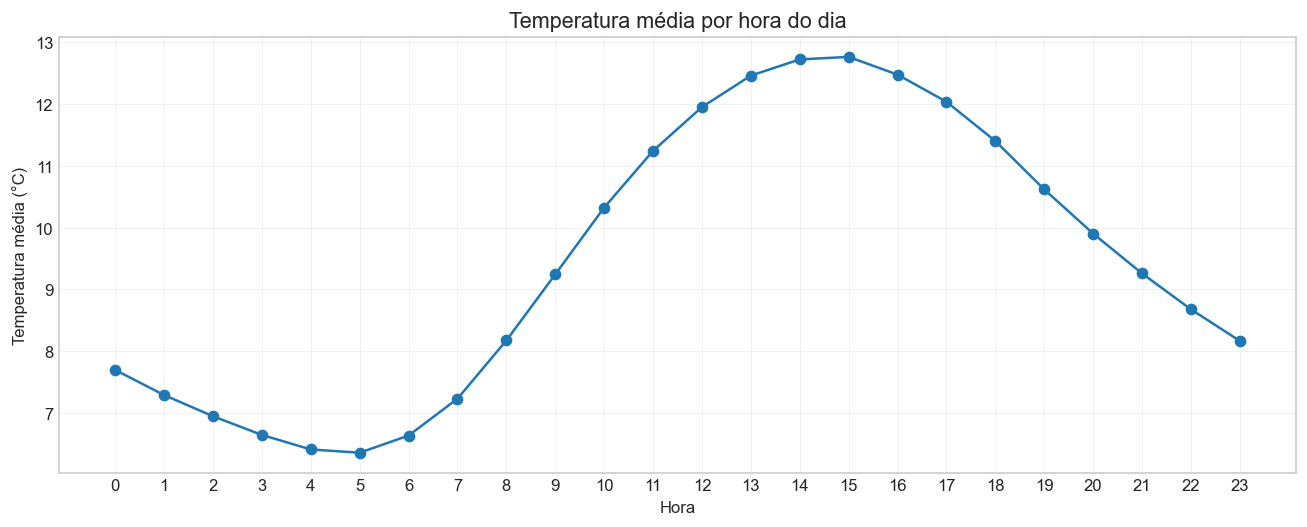

In [4]:
# 3. Média por hora do dia
hour_mean = target.groupby("hour")["T (degC)"].mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(hour_mean.index, hour_mean.values, marker="o", linewidth=1.5)
ax.set_title("Temperatura média por hora do dia")
ax.set_xlabel("Hora")
ax.set_ylabel("Temperatura média (°C)")
ax.set_xticks(range(24))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


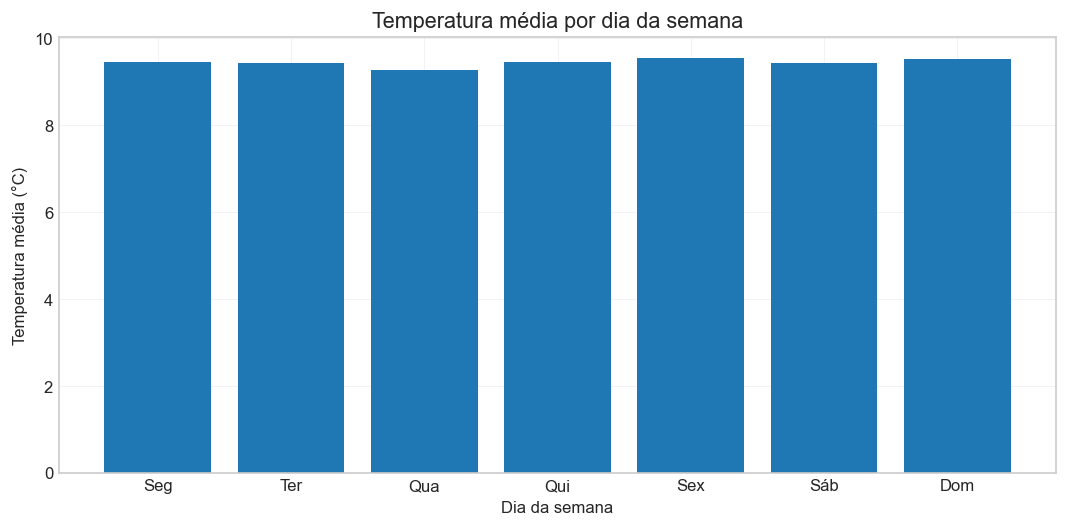

In [5]:
# 4. Média por dia da semana
dow = target.groupby("day_of_week")["T (degC)"].mean()
labels = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(labels, dow.reindex(range(7)).values)
ax.set_title("Temperatura média por dia da semana")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Temperatura média (°C)")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


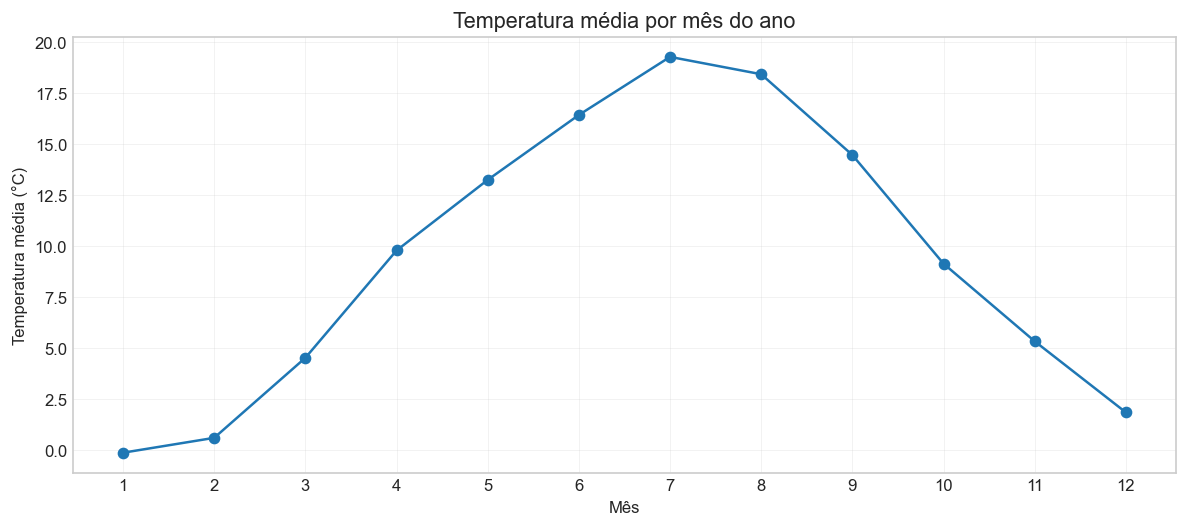

In [6]:
# 5. Média por mês do ano
month_mean = target.groupby("month")["T (degC)"].mean()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(month_mean.index, month_mean.values, marker="o", linewidth=1.5)
ax.set_title("Temperatura média por mês do ano")
ax.set_xlabel("Mês")
ax.set_ylabel("Temperatura média (°C)")
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


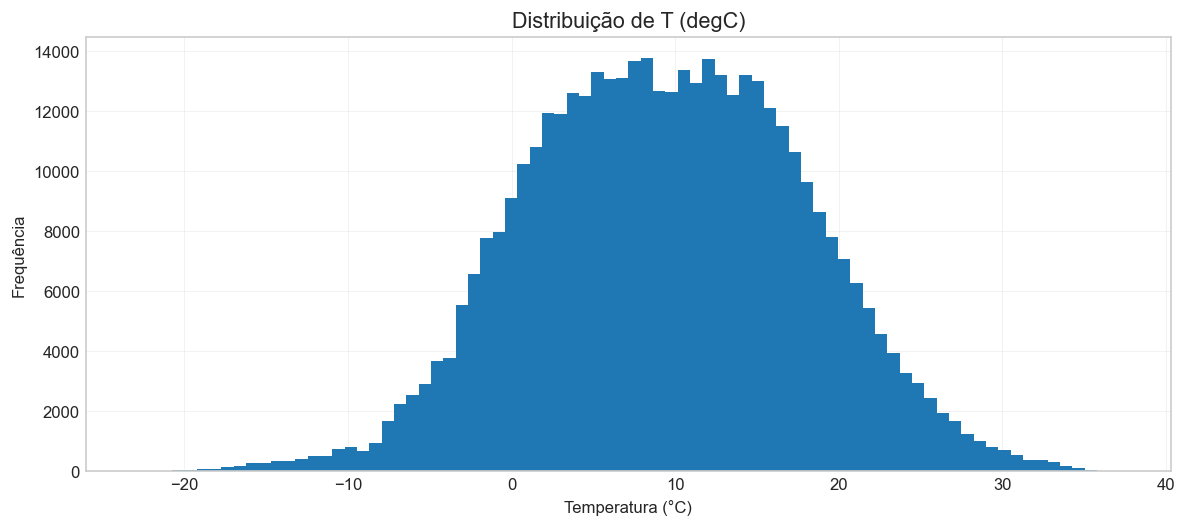

count    420224.000000
mean          9.442421
std           8.421135
min         -23.010000
1%          -10.090000
5%           -3.870000
50%           9.400000
95%          23.140000
99%          28.440000
max          37.280000
Name: T (degC), dtype: float64


In [7]:
# 6. Distribuição da temperatura
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(target["T (degC)"], bins=80)
ax.set_title("Distribuição de T (degC)")
ax.set_xlabel("Temperatura (°C)")
ax.set_ylabel("Frequência")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print(target["T (degC)"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))


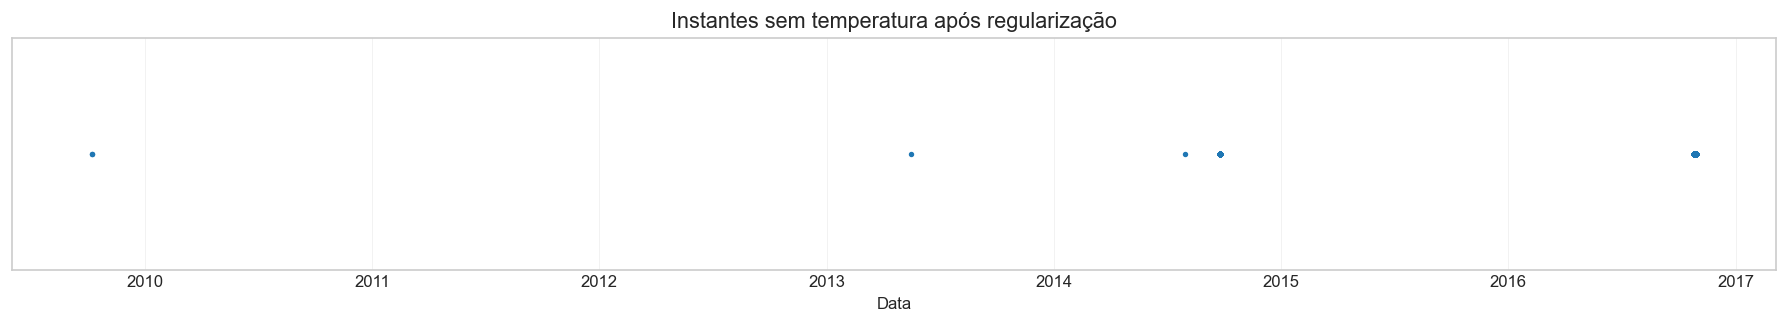

Instantes sem T: 544


In [8]:
# 7. Lacunas na série regularizada
missing = df["T (degC)"].isna()

fig, ax = plt.subplots(figsize=(15, 2.8))
ax.scatter(df.loc[missing, "Date Time"], np.ones(missing.sum()), s=5)
ax.set_title("Instantes sem temperatura após regularização")
ax.set_xlabel("Data")
ax.set_yticks([])
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

print("Instantes sem T:", int(missing.sum()))


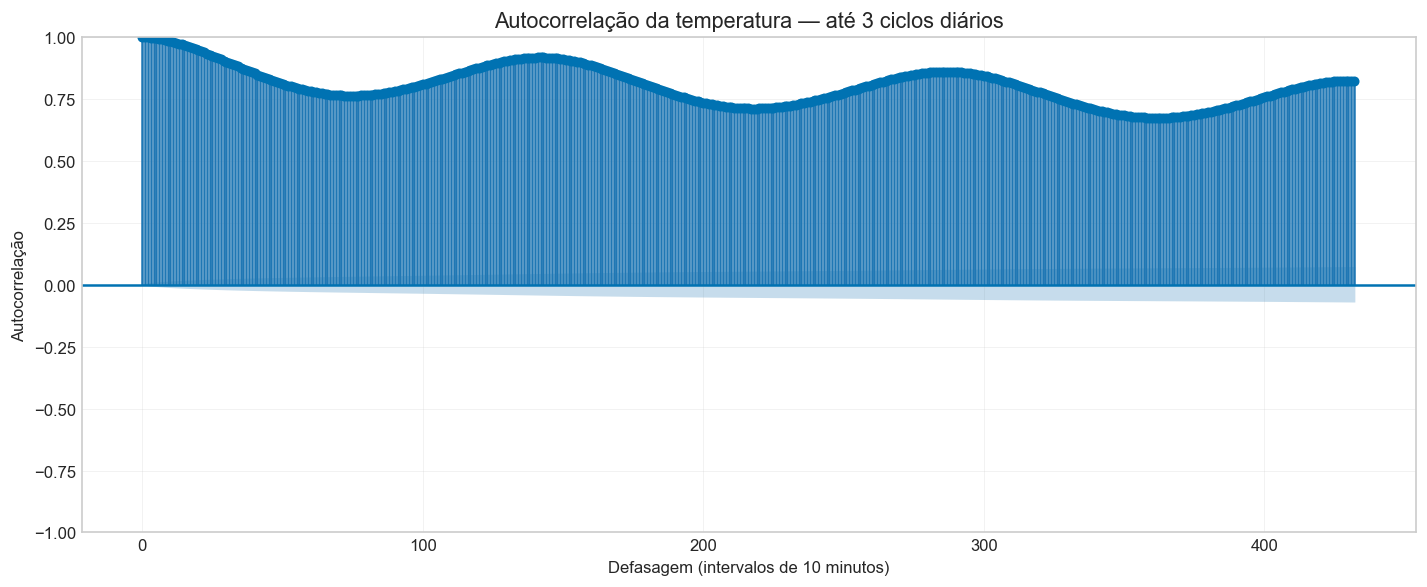

In [9]:
# 8. ACF para as primeiras 3 semanas.
series = target.set_index("Date Time")["T (degC)"]

fig, ax = plt.subplots(figsize=(12, 5))
plotar_acf(ax, series.to_numpy(), lags=3 * 144, unidade="intervalos de 10 minutos")
ax.set_title("Autocorrelação da temperatura — até 3 ciclos diários")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Leitura inicial

Para a Base 4, um ciclo diário equivale a **144 observações** na frequência original de 10 minutos. Um ciclo semanal equivale a **1008 observações**.

A sazonalidade final para Holt-Winters deve ser escolhida considerando os gráficos, a STL e o desempenho no walk-forward. A existência de um padrão visual não é, sozinha, suficiente para fixar o período do modelo.


In [10]:
"""
STL e força da sazonalidade — Base 3 (PM2.5, Pequim) e Base 4 (Temperatura, Jena)
Pacote do P2 (Exploração + Holt-Winters, Bases 3 e 4).

IMPORTANTE — leia antes de colar no notebook:
Os arquivos *_treino_preparada.csv têm buracos na grade temporal, porque a
etapa de preparação faz `dropna(subset=[alvo])` DEPOIS de já ter uma grade
regular. Isso tira as linhas com o alvo ausente e quebra a frequência fixa
(819 horas faltando na janela de treino da Base 3; 99 intervalos de 10 min
faltando na Base 4). STL exige uma série com frequência fixa e sem buracos,
então este script parte dos arquivos *_limpa_preparada.csv (grade completa,
com NaN preservado), recorta a mesma janela cronológica do treino e só então
interpola os poucos pontos faltantes — apenas para esta decomposição
exploratória, não para o treino do modelo em si. Essa é uma decisão que
precisa ser documentada e validada com o grupo, não assumida em silêncio.
"""

from pathlib import Path
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL

BASE_DIR = Path(".")  # ajuste para o caminho das pastas grupo3/ e grupo4/


def seasonal_strength(resid, seasonal):
    """F_S = max(0, 1 - Var(resid) / Var(seasonal + resid))  (Hyndman & Athanasopoulos)."""
    resid, seasonal = np.asarray(resid, float), np.asarray(seasonal, float)
    denom = np.nanvar(seasonal + resid)
    return np.nan if denom == 0 else max(0.0, 1 - np.nanvar(resid) / denom)


def trend_strength(resid, trend):
    resid, trend = np.asarray(resid, float), np.asarray(trend, float)
    denom = np.nanvar(trend + resid)
    return np.nan if denom == 0 else max(0.0, 1 - np.nanvar(resid) / denom)


def preparar_janela_treino(full_csv, treino_csv, col_data, col_alvo, freq):
    treino = pd.read_csv(treino_csv, parse_dates=[col_data])
    inicio, fim = treino[col_data].min(), treino[col_data].max()

    full = pd.read_csv(full_csv, parse_dates=[col_data]).set_index(col_data).sort_index()
    janela = full.loc[inicio:fim, col_alvo].asfreq(freq)
    n_faltando = int(janela.isna().sum())
    janela_interp = janela.interpolate(method="time", limit_direction="both")
    print(f"{col_alvo}: {len(janela)} pontos na janela de treino | "
          f"{n_faltando} pontos interpolados p/ fechar a grade")
    return janela_interp


def rodar_stl(serie, periodos: dict, robust=False):
    resultados = []
    for nome, periodo in periodos.items():
        res = STL(serie, period=periodo, robust=robust).fit()
        resultados.append({
            "periodo": nome,
            "n_obs_por_ciclo": periodo,
            "forca_sazonalidade": round(seasonal_strength(res.resid, res.seasonal), 4),
            "forca_tendencia": round(trend_strength(res.resid, res.trend), 4),
        })
    return pd.DataFrame(resultados)


if __name__ == "__main__":
    # ---------------- Base 4 — Temperatura, grade de 10 min ----------------
    temp = preparar_janela_treino(
        BASE_DIR / "base4_limpa_preparada.csv",
        BASE_DIR / "base4_treino_preparada.csv",
        "Date Time", "T (degC)", "10min",
    )
    tab_b4 = rodar_stl(temp, {"diaria (144)": 144, "semanal (1008)": 1008})
    # sazonalidade anual: agregue para diário antes (period=365), senão fica pesado demais
    print("\nBase 4 — força da sazonalidade (T degC):")
    print(tab_b4.to_string(index=False))

T (degC): 336278 pontos na janela de treino | 99 pontos interpolados p/ fechar a grade

Base 4 — força da sazonalidade (T degC):
       periodo  n_obs_por_ciclo  forca_sazonalidade  forca_tendencia
  diaria (144)              144              0.8605           0.9816
semanal (1008)             1008              0.6250           0.9165
